# BERT机制

## NLP模型：词嵌入word2vec、语言模型

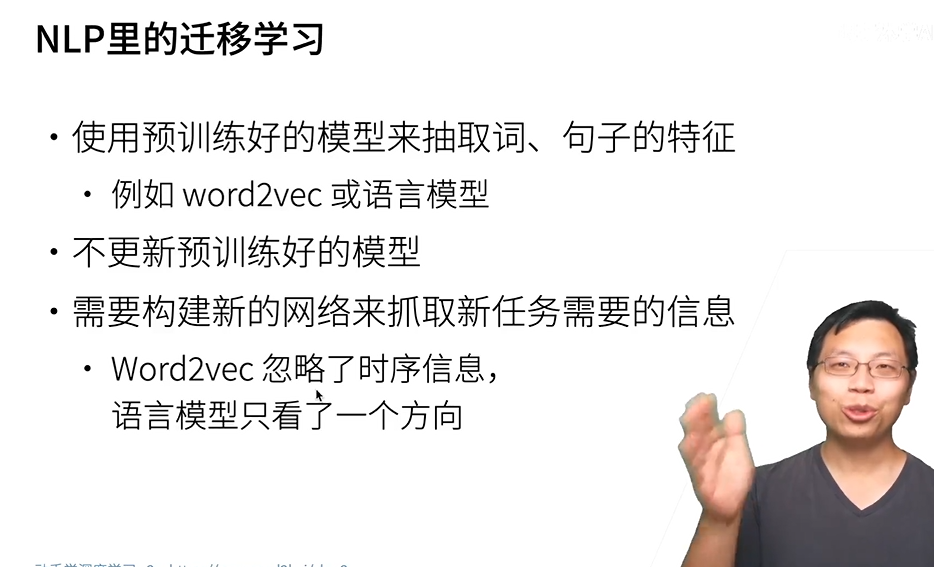

### 词嵌入

**词嵌入（Word2vec）将每个词映射到一个固定长度的向量**，这些向量能更好地表达不同词之间的**相似性和类比关系**。

输入：通常使用独热（one-hot）编码表示单词。**但独热向量不能编码词之间的相似性。**

映射（隐含）层：将高维的输入向量压缩成一个低维的、稠密的向量，这个向量就是该词的词嵌入。

输出层：经过计算，输出一个和词汇表大小相同的向量，再通过 $Softmax$ 函数转换成概率分布，表示每个词是目标词的概率

Word2vec包含两种经典的训练模型，它们的目标恰好相反。

1. 连续词袋模型 (CBOW)

    目标：根据上下文（周围的词）来预测当前词。

    类比：给你一句话“__是中国的首都”，让你猜横线处是“北京”。

    特点：输入是多个上下文词，输出是一个目标词。训练速度相对较快，在句法任务上表现稍好。

2. Skip-gram模型

    目标：根据当前词来预测它的上下文（周围的词）。

    类比：给你“北京”这个词，让你猜它可能出现在“__是中国的首都”这样的语境中。

    特点：输入是一个词，输出是多个上下文词。虽然训练较慢，但在处理罕见词和语义任务上表现更优。

Embedding（嵌入）：是一个数学/技术概念。它指代将高维、离散的符号（如文字、ID、类别）映射到低维、稠密、连续的实数向量空间的过程。任何能把“非数值”变成“数值向量”的操作，都叫 Embedding。

Word2vec：是一个具体的算法/模型。它是专门针对“单词”这种符号，利用神经网络（CBOW/Skip-gram）来学习向量的具体实现。

但word2vec忽视了文本顺序

### 语言模型

**语言模型（Language Model, LM）是用来计算句子出现概率或预测下一个词**的数学模型。它的核心目标是判断“哪段文字序列更符合人类语言的语法和逻辑习惯”。

输入：通常是一个词序列。与Word2vec静态的独热编码不同，现代语言模型的输入层包含可训练的Embedding矩阵，并且会结合位置编码（Positional Encoding），以捕捉词的先后顺序。

核心计算层（特征提取）：将输入的词向量序列转化为包含上下文信息的深层语义表示。它必须能处理长距离依赖。

1. 早期：基于马尔可夫假设的n-gram（统计频次）。

2. 中期：RNN / LSTM（循环神经网络，按顺序记忆）。

3. 现在：Transformer架构（基于自注意力机制，能同时看到所有位置的词，并行计算）。

输出层：与Word2vec类似，最后会通过一个线性层（全连接）将隐藏状态映射为和词汇表大小相同的向量，再经过 Softmax 函数转换为概率分布，用来决定下一个词或被掩码的词是谁。

早期语言模型只能看一个方向，现代语言模型以GPT和BERT为代表

## BERT

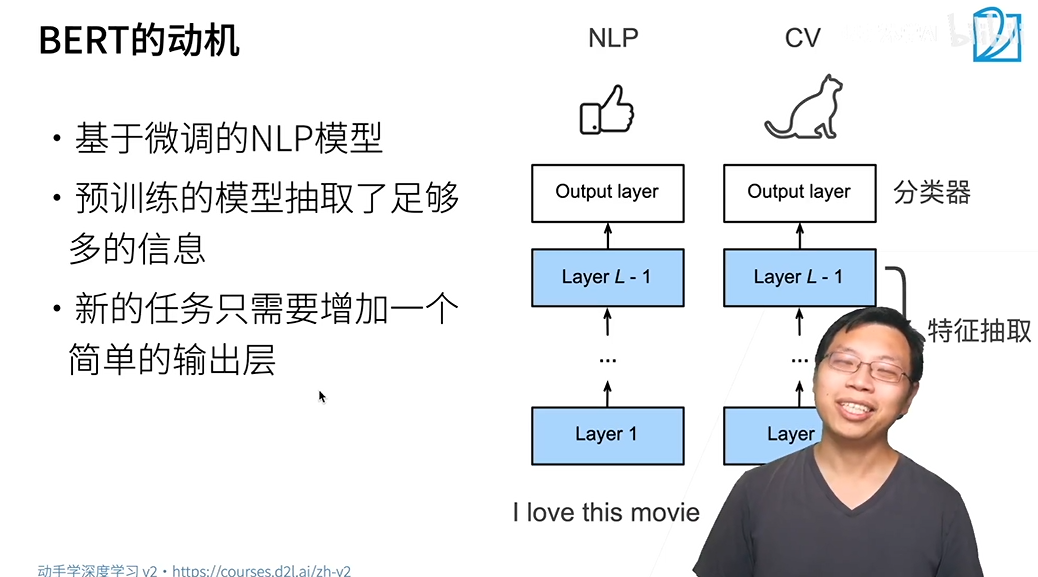

bert 核心思想是“预训练（Pre-training）+ 微调（Fine-tuning）”。

预训练阶段，BERT在海量无标注文本（如维基百科）上，通过自监督方式学习，不依赖人工标注

当有一个具体的NLP任务时，“微调”阶段才开始:

1. 直接加载一个已经预训练好的BERT模型作为起点。

2. 在BERT模型之上，增加一个非常简单的、任务相关的输出层。例如：

    文本分类：加一个全连接层，把输出映射到不同的类别。

    问答系统：加一个能预测答案起始和结束位置的层。

3. 用少量任务相关标注数据，对整个模型（或部分层）进行短时间的训练。

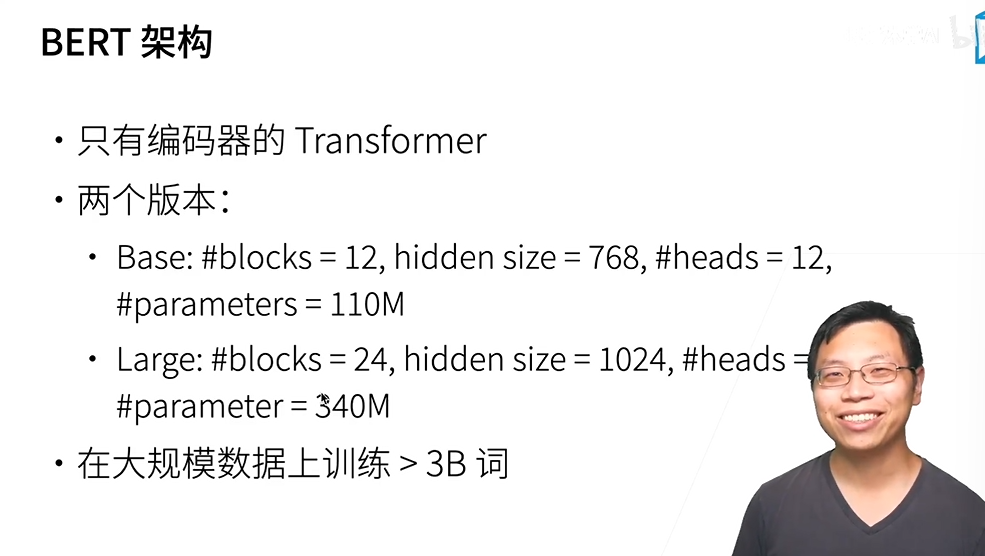

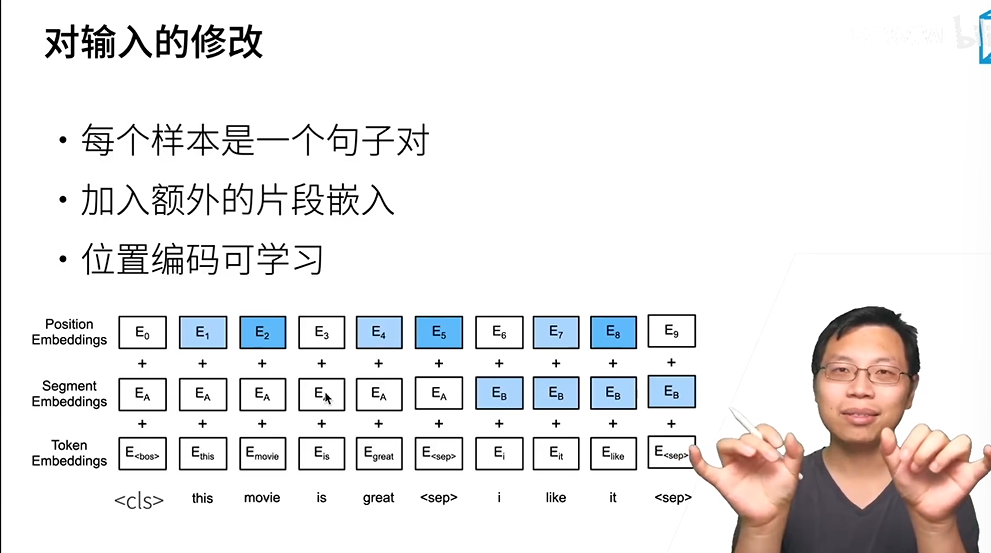

每个词嵌入 + 所属句子嵌入 + 绝对顺序位置嵌入

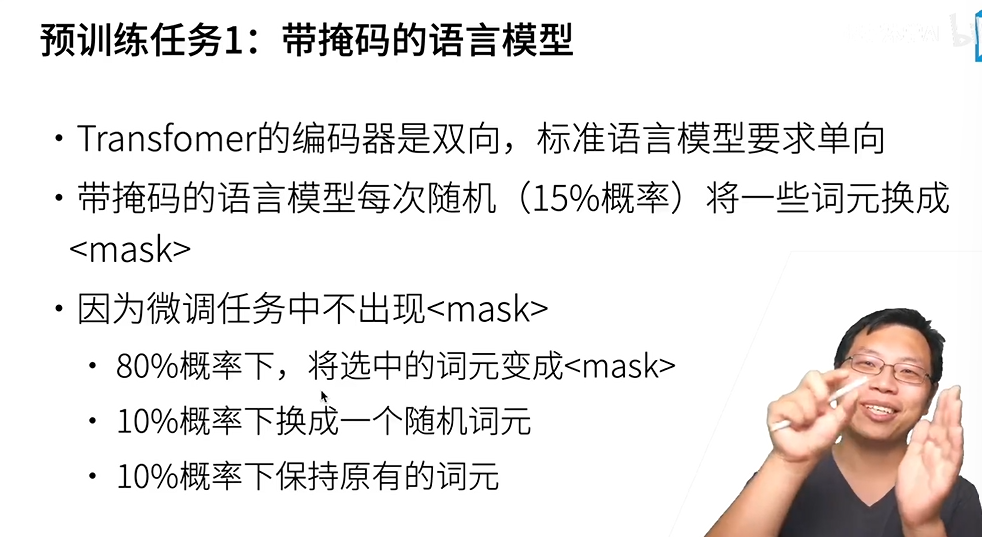

transformer 的编码器，是能看到前后信息的双向模型，但标准语言模型要求单向，所以加 mask

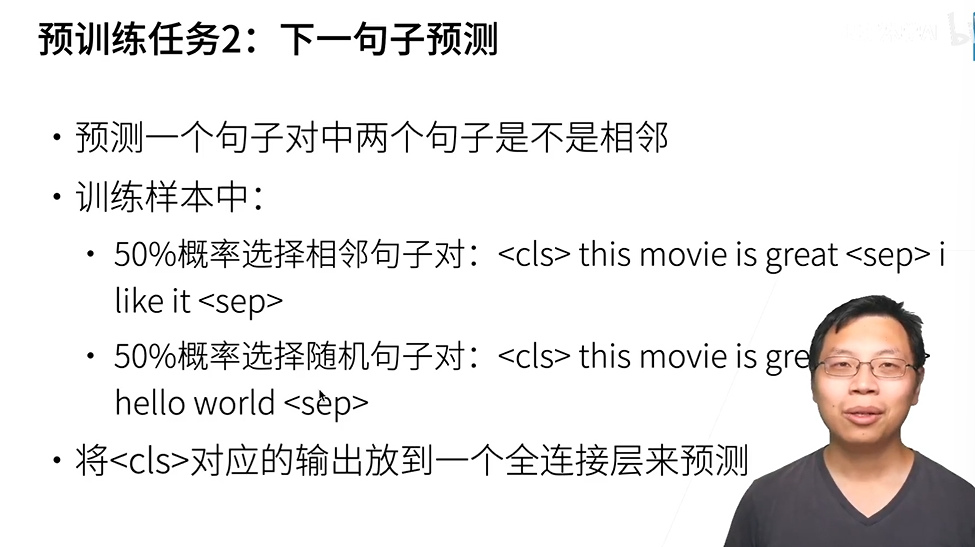

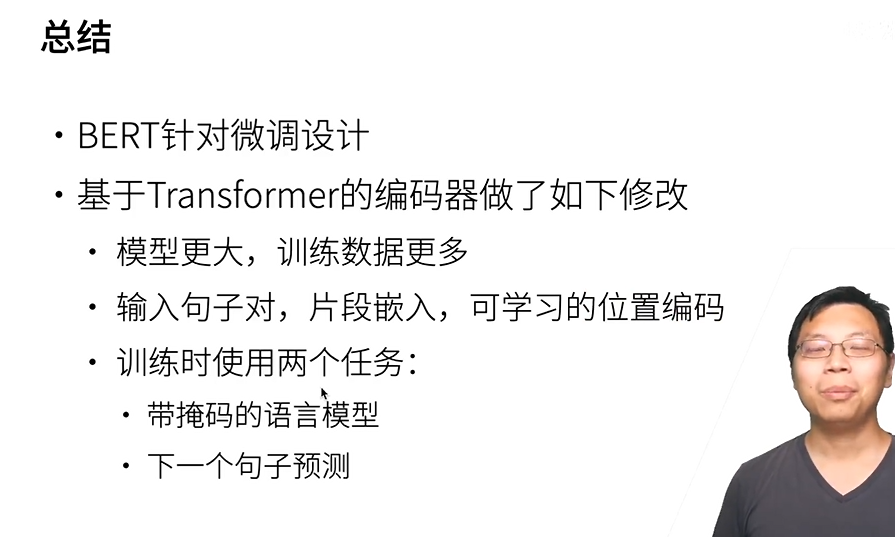